In [150]:
# import libraries
import pandas as pd
import numpy as np
!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.stats import t 
from sklearn.decomposition import PCA
from scipy.stats.contingency import association
#import OLS 
from statsmodels.formula.api import ols

In [151]:
#Importing Data and removing nulls and nans
filename = 'churn_clean.csv'
df = pd.read_csv(filename, na_values = ['null','N/A',' ', '', '.','nan']) 

In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  str    
 2   Interaction           10000 non-null  str    
 3   UID                   10000 non-null  str    
 4   City                  10000 non-null  str    
 5   State                 10000 non-null  str    
 6   County                10000 non-null  str    
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  str    
 12  TimeZone              10000 non-null  str    
 13  Job                   10000 non-null  str    
 14  Children              10000 non-null  int64  
 15  Age                   10000 non

In [153]:
df.describe()


,CaseOrder,Zip,Lat,Lng,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,49153.319600,38.757567,-90.782536,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,27532.196108,5.437389,15.156142,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,601.000000,17.966120,-171.688150,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,26292.500000,35.341828,-97.082812,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,48869.500000,39.395800,-87.918800,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,71866.500000,42.106908,-80.088745,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,99929.000000,70.640660,-65.667850,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


In [154]:
pd.set_option('display.max_columns', None)

print(df.head())

   CaseOrder Customer_id                           Interaction  \
0          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

                                UID         City State                 County  \
0  e885b299883d4f9fb18e39c75155d990  Point Baker    AK  Prince of Wales-Hyder   
1  f2de8bef964785f41a2959829830fb8a  West Branch    MI                 Ogemaw   
2  f1784cfa9f6d92ae816197eb175d3c71      Yamhill    OR                Yamhill   
3  dc8a365077241bb5cd5ccd305136b05e      Del Mar    CA              San Diego   
4  aabb64a116e83fdc4befc1fbab1663f9    Needville    TX              Fort Bend   

     Zip       Lat        Lng  Population      Area             TimeZone  \
0  99927  56.25100 -133.37571          3

In [155]:
#Reducing the Dataset to relevant columns for multiple Linear Regression

df_model = df[
    [
        'MonthlyCharge',
        'Bandwidth_GB_Year',
        'Income',
        'Tenure',
        'Population',
        'Children',
        'Contract',
        'InternetService',
        'Phone',
        'StreamingTV',
        'StreamingMovies',
        'TechSupport',
        'OnlineSecurity',
        'Area',
        
        
    ]
]


In [156]:
#Checking for missing values across all columns in the subsetted dataset
print(df_model.isna().sum())

MonthlyCharge           0
Bandwidth_GB_Year       0
Income                  0
Tenure                  0
Population              0
Children                0
Contract                0
InternetService      2129
Phone                   0
StreamingTV             0
StreamingMovies         0
TechSupport             0
OnlineSecurity          0
Area                    0
dtype: int64


In [157]:

print(df_model['InternetService'].value_counts())

InternetService
Fiber Optic    4408
DSL            3463
Name: count, dtype: int64


In [158]:
#Filling InternetService missing data with "None", since the customer could have internet service from another company. 
#The customer possibly only uses phone/tv services from this company

df_model['InternetService'] = df_model['InternetService'].fillna('None')



In [159]:

print(df_model['InternetService'].value_counts())


InternetService
Fiber Optic    4408
DSL            3463
None           2129
Name: count, dtype: int64


In [160]:
#Checking subsetted dataset 

df_model.isnull().sum()

MonthlyCharge        0
Bandwidth_GB_Year    0
Income               0
Tenure               0
Population           0
Children             0
Contract             0
InternetService      0
Phone                0
StreamingTV          0
StreamingMovies      0
TechSupport          0
OnlineSecurity       0
Area                 0
dtype: int64

In [161]:
#Checking Datatypes of subset dataset

df_model.dtypes


MonthlyCharge        float64
Bandwidth_GB_Year    float64
Income               float64
Tenure               float64
Population             int64
Children               int64
Contract                 str
InternetService          str
Phone                    str
StreamingTV              str
StreamingMovies          str
TechSupport              str
OnlineSecurity           str
Area                     str
dtype: object

In [162]:
# Convert categorical variables to category dtype for regression analysis
cat_cols = [
    'Contract',
    'InternetService',
    'Phone',                   
    'StreamingTV',
    'StreamingMovies',
    'TechSupport',
    'OnlineSecurity',
    'Area',
    'Contract'
]

for col in cat_cols:
    df_model[col] = df_model[col].astype('category')

In [163]:
#Double check dtypes

df_model.dtypes

MonthlyCharge         float64
Bandwidth_GB_Year     float64
Income                float64
Tenure                float64
Population              int64
Children                int64
Contract             category
InternetService      category
Phone                category
StreamingTV          category
StreamingMovies      category
TechSupport          category
OnlineSecurity       category
Area                 category
dtype: object

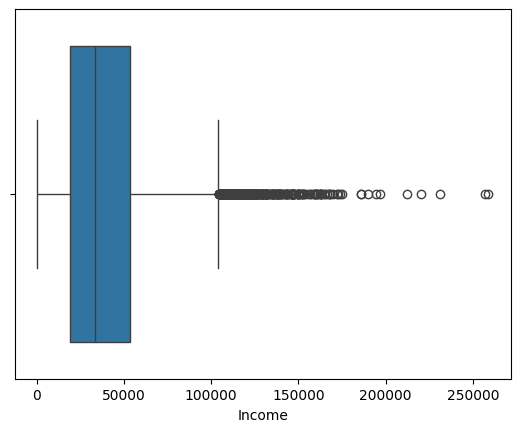

In [164]:
#Creating Boxplot with Income, to check for outliers 

income_box = sns.boxplot(x='Income',data=df_model)

In [165]:
#Capping max values at 175k 

df_model.loc[df_model['Income'] > 175000, 'Income'] = 175000


In [166]:
#Checking max income and reassurance

print(df_model['Income'].max())
print(df_model['Income'].count())

175000.0
10000


<Axes: xlabel='MonthlyCharge'>

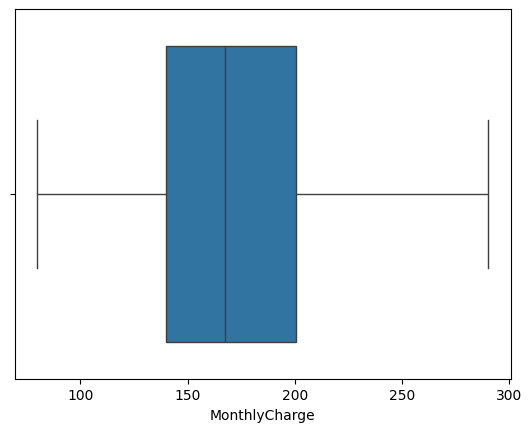

In [167]:
#Boxplot for MonthlyCharge, to check for outliers

sns.boxplot(x='MonthlyCharge',data=df_model)

<Axes: xlabel='Bandwidth_GB_Year'>

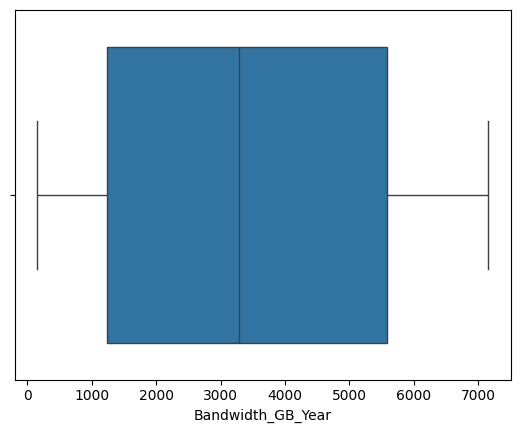

In [168]:
#Boxplot for Bandwidth_GB_Year, to check for outliers

sns.boxplot(x='Bandwidth_GB_Year',data=df_model)

<Axes: xlabel='Tenure'>

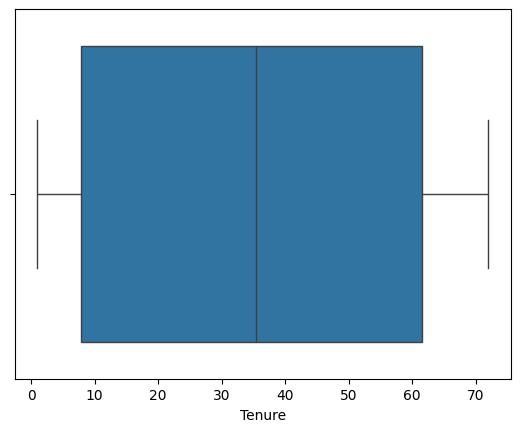

In [169]:
#Boxplot for Tenure, to check for outliers

sns.boxplot(x='Tenure',data=df_model)

<Axes: xlabel='Population'>

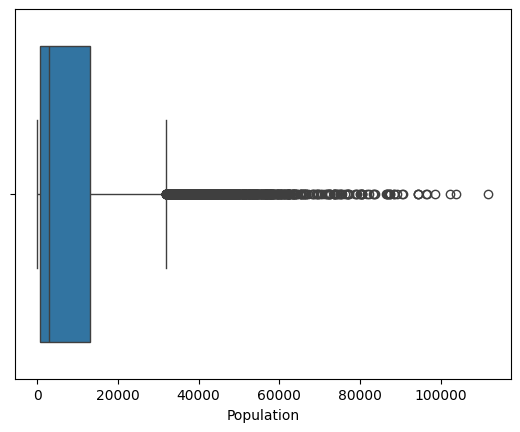

In [170]:
#Boxplot for Population, to check for outliers

sns.boxplot(x='Population',data=df_model)

401


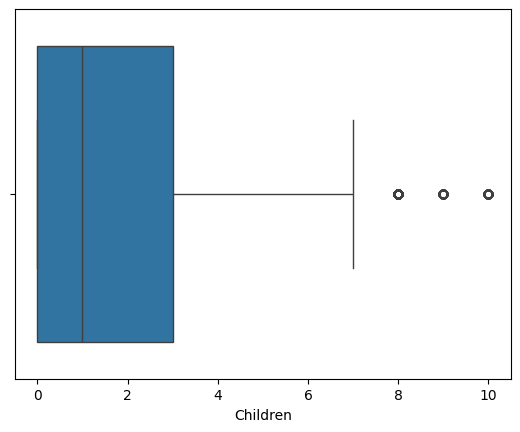

In [171]:
#Boxplot for Children, to check for outliers

sns.boxplot(x='Children',data=df_model)

print((df_model['Children'] > 7).sum())


In [172]:
#Printing Summary and valuecounts for continous variable

print("Summary")
print(df_model.describe())

print("Value counts")
print(df_model.describe(include='category'))


Summary
       MonthlyCharge  Bandwidth_GB_Year         Income        Tenure  \
count   10000.000000       10000.000000   10000.000000  10000.000000   
mean      172.624816        3392.341550   39768.591427     34.526188   
std        42.943094        2185.294852   27976.727587     26.443063   
min        79.978860         155.506715     348.670000      1.000259   
25%       139.979239        1236.470827   19224.717500      7.917694   
50%       167.484700        3279.536903   33170.605000     35.430507   
75%       200.734725        5586.141370   53246.170000     61.479795   
max       290.160419        7158.981530  175000.000000     71.999280   

          Population    Children  
count   10000.000000  10000.0000  
mean     9756.562400      2.0877  
std     14432.698671      2.1472  
min         0.000000      0.0000  
25%       738.000000      0.0000  
50%      2910.500000      1.0000  
75%     13168.000000      3.0000  
max    111850.000000     10.0000  
Value counts
              C

Print Summary statistics for C2


In [174]:
#Printing summary statistics of MonthlyCharge

print(df_model['MonthlyCharge'].describe())

print('Range:',df_model['MonthlyCharge'].max() - df_model['MonthlyCharge'].min())

count    10000.000000
mean       172.624816
std         42.943094
min         79.978860
25%        139.979239
50%        167.484700
75%        200.734725
max        290.160419
Name: MonthlyCharge, dtype: float64
Range: 210.181559


In [175]:
#Printing summary statistics of Bandwidth_GB_Year

print(df_model['Bandwidth_GB_Year'].describe())

print('Range:',df_model['Bandwidth_GB_Year'].max() - df_model['Bandwidth_GB_Year'].min())

count    10000.000000
mean      3392.341550
std       2185.294852
min        155.506715
25%       1236.470827
50%       3279.536903
75%       5586.141370
max       7158.981530
Name: Bandwidth_GB_Year, dtype: float64
Range: 7003.4748152


In [176]:
#Printing summary statistics of Income

print(df_model['Income'].describe())

print('Range:',df_model['Income'].max() - df_model['Income'].min())

count     10000.000000
mean      39768.591427
std       27976.727587
min         348.670000
25%       19224.717500
50%       33170.605000
75%       53246.170000
max      175000.000000
Name: Income, dtype: float64
Range: 174651.33


In [177]:
#Printing summary statistics of Tenure

print(df_model['Tenure'].describe())

print('Range:',df_model['Tenure'].max() - df_model['Tenure'].min())

count    10000.000000
mean        34.526188
std         26.443063
min          1.000259
25%          7.917694
50%         35.430507
75%         61.479795
max         71.999280
Name: Tenure, dtype: float64
Range: 70.99902066


In [178]:
#Printing summary statistics of Population

print(df_model['Population'].describe())

print('Range:',df_model['Population'].max() - df_model['Population'].min())

count     10000.000000
mean       9756.562400
std       14432.698671
min           0.000000
25%         738.000000
50%        2910.500000
75%       13168.000000
max      111850.000000
Name: Population, dtype: float64
Range: 111850


In [179]:
#Printing summary statistics of Children

print(df_model['Children'].describe())

print('Range:',df_model['Children'].max() - df_model['Children'].min())

count    10000.0000
mean         2.0877
std          2.1472
min          0.0000
25%          0.0000
50%          1.0000
75%          3.0000
max         10.0000
Name: Children, dtype: float64
Range: 10


In [180]:
#Printing summary for Contract

print(df_model['Contract'].value_counts())
print(df_model['Contract'].value_counts(normalize=True) * 100)

Contract
Month-to-month    5456
Two Year          2442
One year          2102
Name: count, dtype: int64
Contract
Month-to-month    54.56
Two Year          24.42
One year          21.02
Name: proportion, dtype: float64


In [181]:
#Printing summary for InternetService

print(df_model['InternetService'].value_counts())
print(df_model['InternetService'].value_counts(normalize=True) * 100)

InternetService
Fiber Optic    4408
DSL            3463
None           2129
Name: count, dtype: int64
InternetService
Fiber Optic    44.08
DSL            34.63
None           21.29
Name: proportion, dtype: float64


In [182]:
#Printing summary for Phone

print(df_model['Phone'].value_counts())
print(df_model['Phone'].value_counts(normalize=True) * 100)

Phone
Yes    9067
No      933
Name: count, dtype: int64
Phone
Yes    90.67
No      9.33
Name: proportion, dtype: float64


In [183]:
#Printing summary for StreamingTV

print(df_model['StreamingTV'].value_counts())
print(df_model['StreamingTV'].value_counts(normalize=True) * 100)

StreamingTV
No     5071
Yes    4929
Name: count, dtype: int64
StreamingTV
No     50.71
Yes    49.29
Name: proportion, dtype: float64


In [184]:
#Printing summary for StreamingMovies

print(df_model['StreamingMovies'].value_counts())
print(df_model['StreamingMovies'].value_counts(normalize=True) * 100)

StreamingMovies
No     5110
Yes    4890
Name: count, dtype: int64
StreamingMovies
No     51.1
Yes    48.9
Name: proportion, dtype: float64


In [185]:
#Printing summary for TechSupport

print(df_model['TechSupport'].value_counts())
print(df_model['TechSupport'].value_counts(normalize=True) * 100)

TechSupport
No     6250
Yes    3750
Name: count, dtype: int64
TechSupport
No     62.5
Yes    37.5
Name: proportion, dtype: float64


In [186]:
#Printing summary for OnlineSecurity

print(df_model['OnlineSecurity'].value_counts())
print(df_model['OnlineSecurity'].value_counts(normalize=True) * 100)

OnlineSecurity
No     6424
Yes    3576
Name: count, dtype: int64
OnlineSecurity
No     64.24
Yes    35.76
Name: proportion, dtype: float64


In [187]:
#Printing summary for Area

print(df_model['Area'].value_counts())
print(df_model['Area'].value_counts(normalize=True) * 100)

Area
Suburban    3346
Rural       3327
Urban       3327
Name: count, dtype: int64
Area
Suburban    33.46
Rural       33.27
Urban       33.27
Name: proportion, dtype: float64


In [188]:
print(df_model.columns)

Index(['MonthlyCharge', 'Bandwidth_GB_Year', 'Income', 'Tenure', 'Population',
       'Children', 'Contract', 'InternetService', 'Phone', 'StreamingTV',
       'StreamingMovies', 'TechSupport', 'OnlineSecurity', 'Area'],
      dtype='str')


C3: Generate univariate and bivariate visualizations of the distributions of the dependent and independent variables, including the dependent variable in your bivariate visualizations.

<Axes: xlabel='MonthlyCharge', ylabel='Count'>

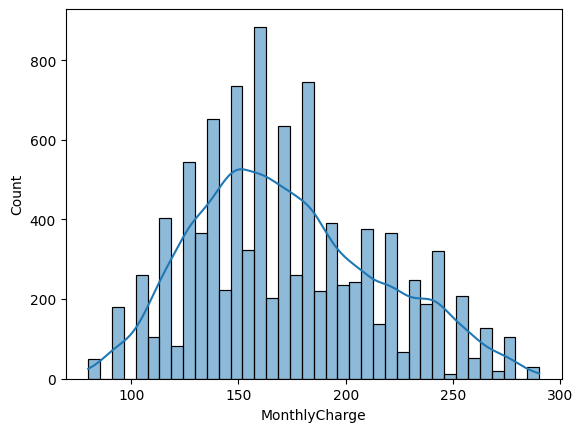

In [190]:
#Generating Univariate graph for Response variable MonthlyCharge

sns.histplot(df_model['MonthlyCharge'], kde=True)


<Axes: xlabel='Bandwidth_GB_Year', ylabel='Count'>

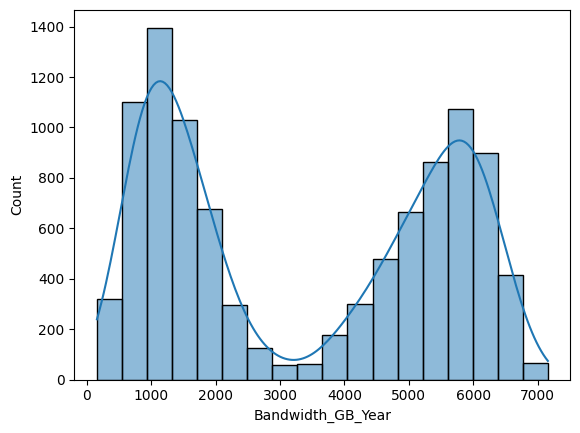

In [191]:
#Histogram for Bandwidth_GB_Year
sns.histplot(df_model['Bandwidth_GB_Year'], kde=True)

<Axes: xlabel='Income', ylabel='Count'>

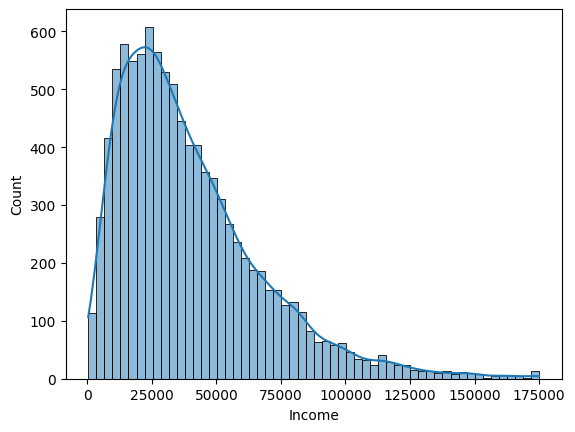

In [192]:
#Histogram for Income 

sns.histplot(df_model['Income'], kde=True)

<Axes: xlabel='Tenure', ylabel='Count'>

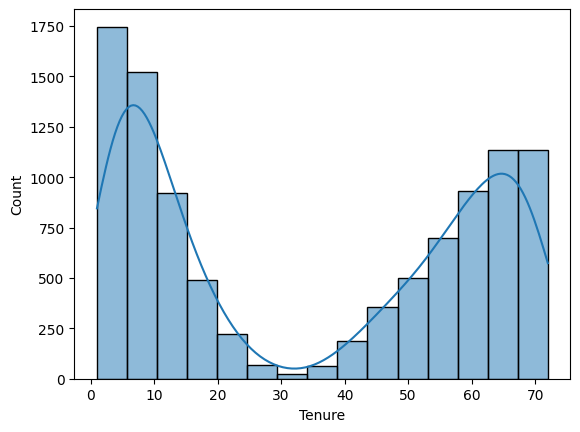

In [193]:
#Barchart for Tenure

sns.histplot(df_model['Tenure'], kde=True)


<Axes: xlabel='Population', ylabel='Count'>

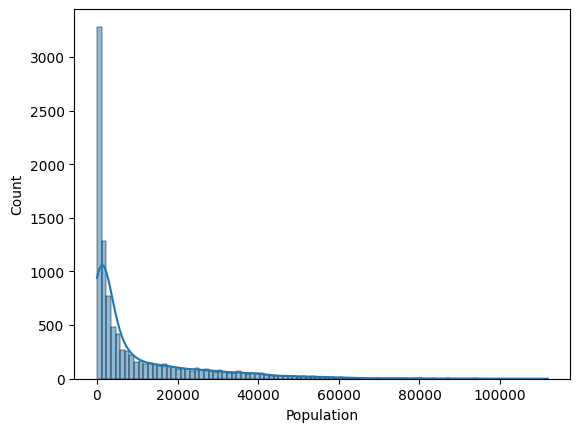

In [194]:
#Barchart for Population

sns.histplot(df_model['Population'], kde=True)


<Axes: xlabel='Children', ylabel='Count'>

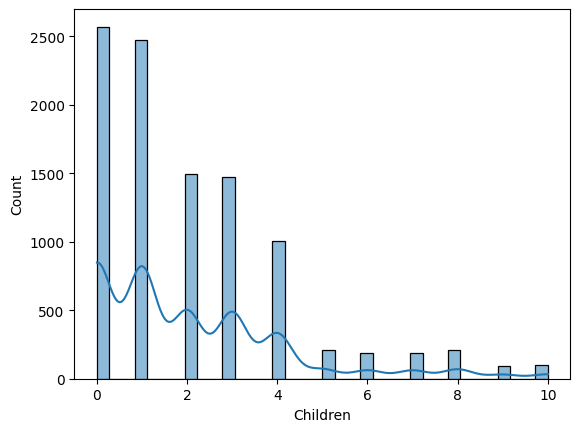

In [195]:
#Barchart for Children

sns.histplot(df_model['Children'], kde=True)


<Axes: xlabel='Contract', ylabel='count'>

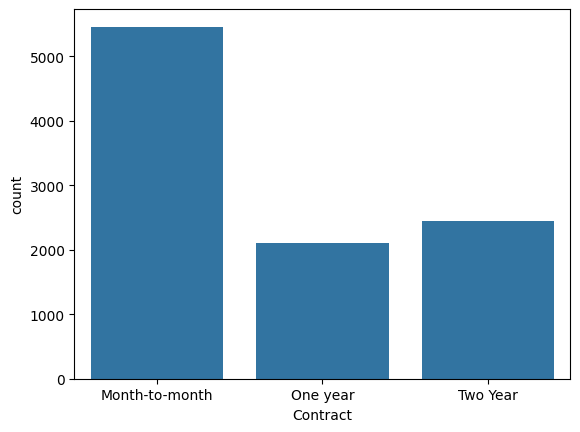

In [196]:
#Barchart for Contract

sns.countplot(x='Contract', data=df_model)


<Axes: xlabel='InternetService', ylabel='count'>

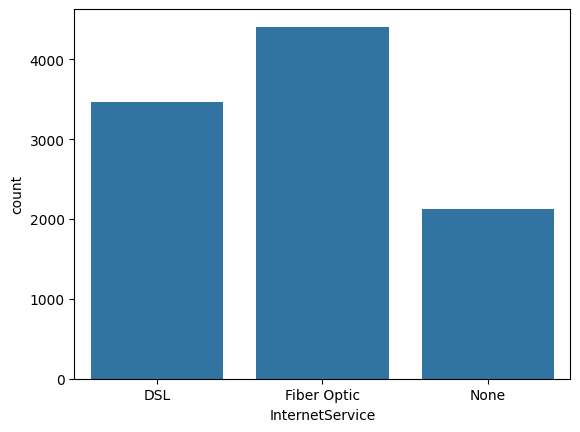

In [197]:
#Barchart for InternetService

sns.countplot(x='InternetService', data=df_model)


<Axes: xlabel='Phone', ylabel='count'>

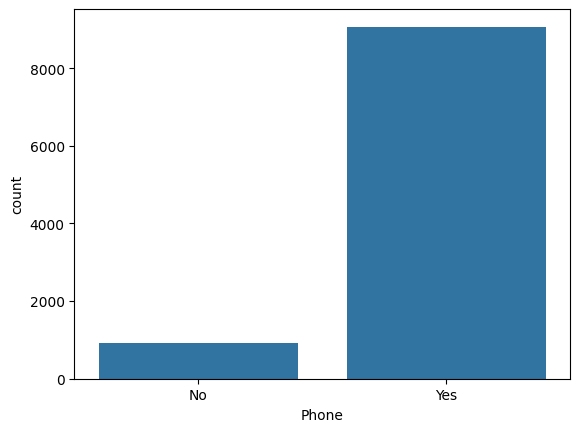

In [198]:
#Barchart for Phone

sns.countplot(x='Phone', data=df_model)


<Axes: xlabel='StreamingTV', ylabel='count'>

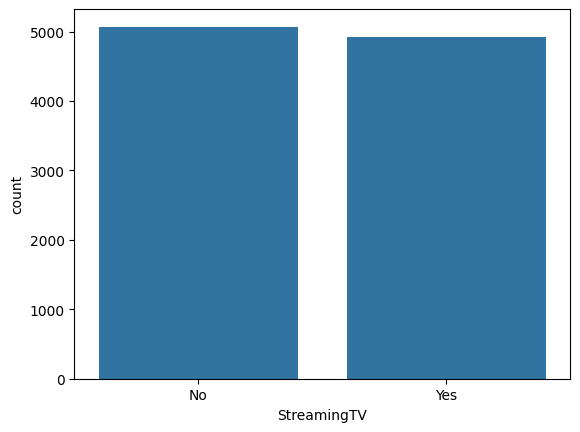

In [199]:
#Barchart for StreamingTV

sns.countplot(x='StreamingTV', data=df_model)


<Axes: xlabel='StreamingMovies', ylabel='count'>

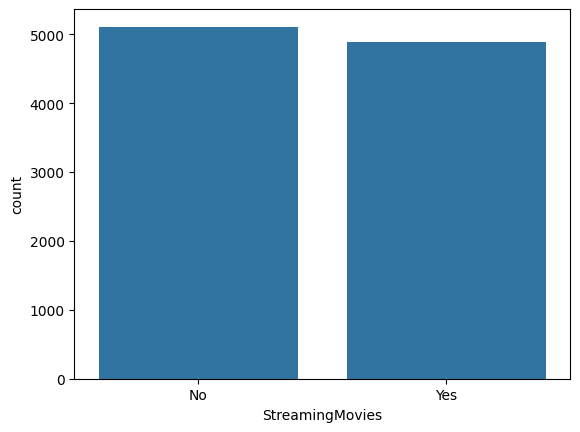

In [200]:
#Barchart for StreamingMovies

sns.countplot(x='StreamingMovies', data=df_model)


<Axes: xlabel='TechSupport', ylabel='count'>

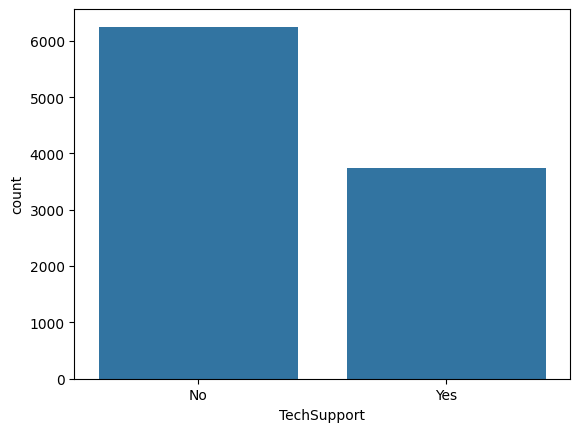

In [201]:
#Barchart for TechSupport

sns.countplot(x='TechSupport', data=df_model)


<Axes: xlabel='OnlineSecurity', ylabel='count'>

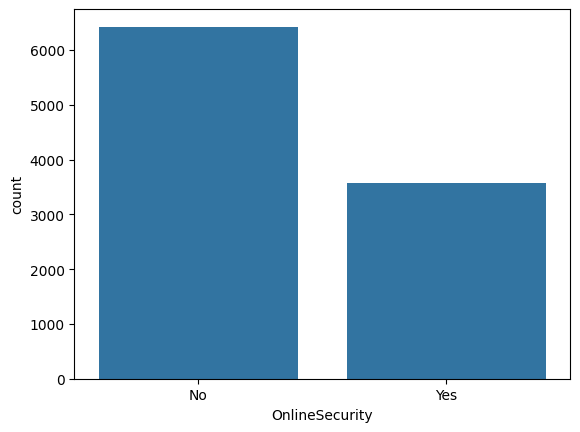

In [202]:
#Barchart for OnlineSecurity

sns.countplot(x='OnlineSecurity', data=df_model)


<Axes: xlabel='Area', ylabel='count'>

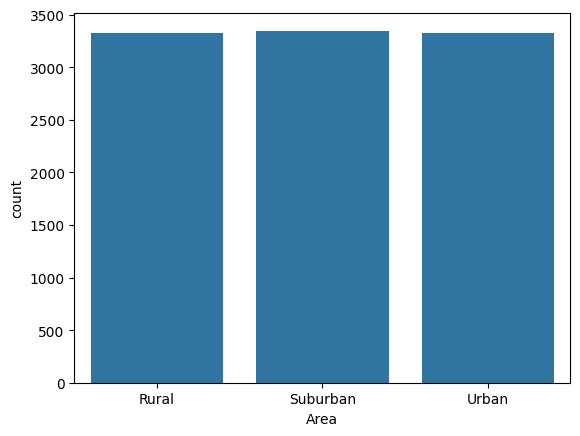

In [203]:
#Barchart for Area

sns.countplot(x='Area', data=df_model)


Bivariate Graphs with Response + Explanatory


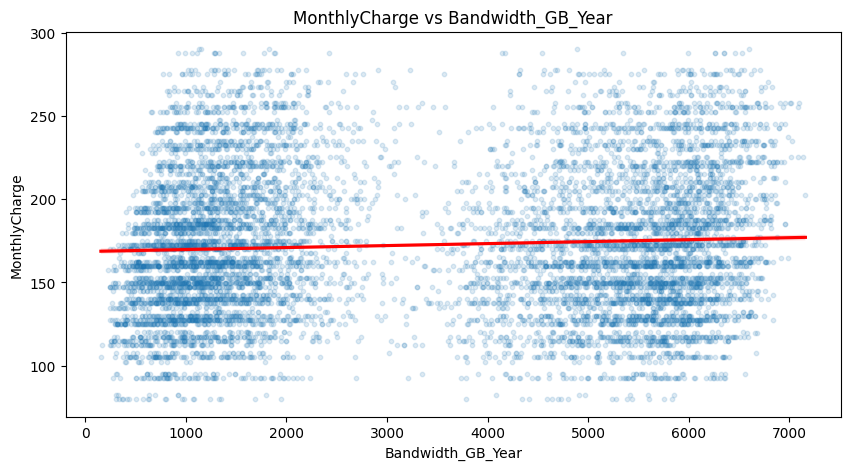

In [205]:
#Bivariate MonthlyCharge x Bandwidth_GB_Year


plt.figure(figsize=(10,5))
sns.regplot(
    x='Bandwidth_GB_Year',
    y='MonthlyCharge',
    data=df_model,
    scatter_kws={'alpha':0.15, 's':10},
    line_kws={'color':'red'}
)
plt.title('MonthlyCharge vs Bandwidth_GB_Year')
plt.show()

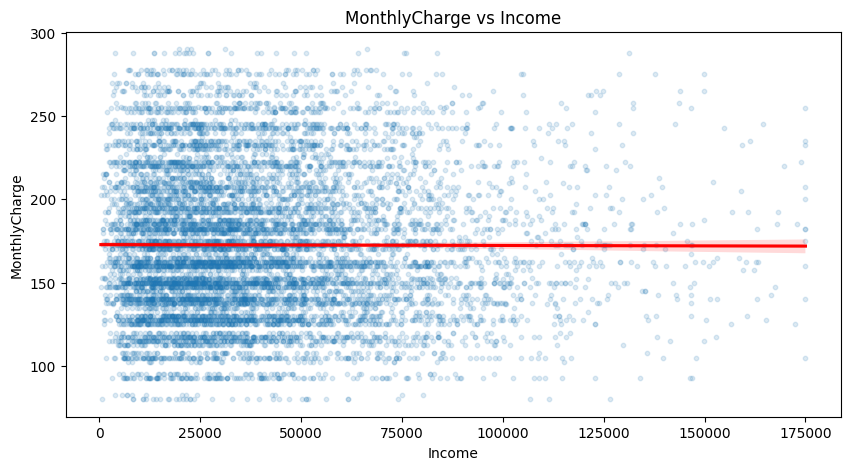

In [206]:
#Bivariate MonthlyCharge x Income


plt.figure(figsize=(10,5))
sns.regplot(
    x='Income',
    y='MonthlyCharge',
    data=df_model,
    scatter_kws={'alpha':0.15, 's':10},
    line_kws={'color':'red'}
)
plt.title('MonthlyCharge vs Income')
plt.show()

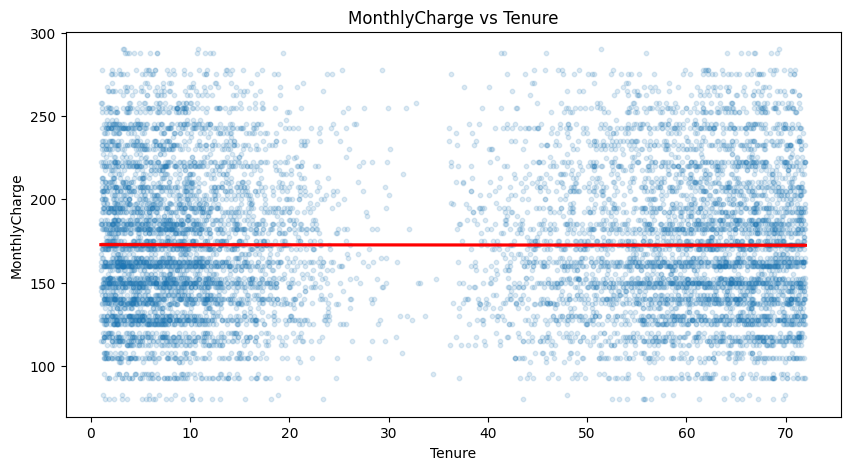

In [207]:
#Bivariate MonthlyCharge x Tenure


plt.figure(figsize=(10,5))
sns.regplot(
    x='Tenure',
    y='MonthlyCharge',
    data=df_model,
    scatter_kws={'alpha':0.15, 's':10},
    line_kws={'color':'red'}
)
plt.title('MonthlyCharge vs Tenure')
plt.show()

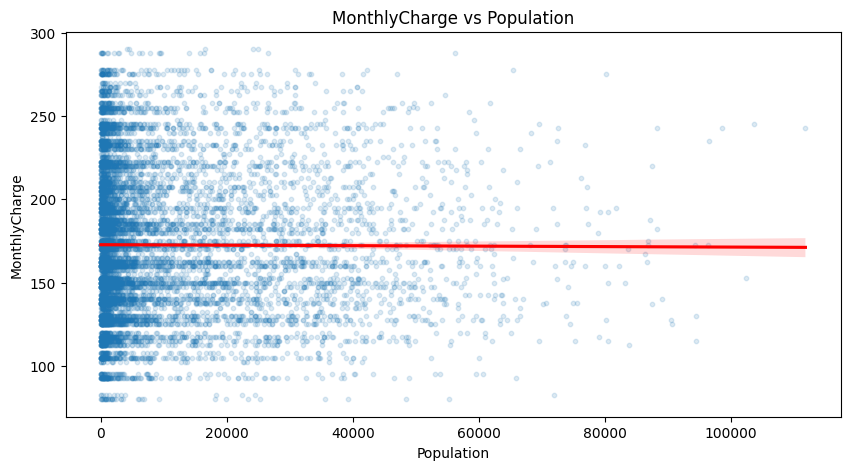

In [208]:
#Bivariate MonthlyCharge x Population


plt.figure(figsize=(10,5))
sns.regplot(
    x='Population',
    y='MonthlyCharge',
    data=df_model,
    scatter_kws={'alpha':0.15, 's':10},
    line_kws={'color':'red'}
)
plt.title('MonthlyCharge vs Population')
plt.show()

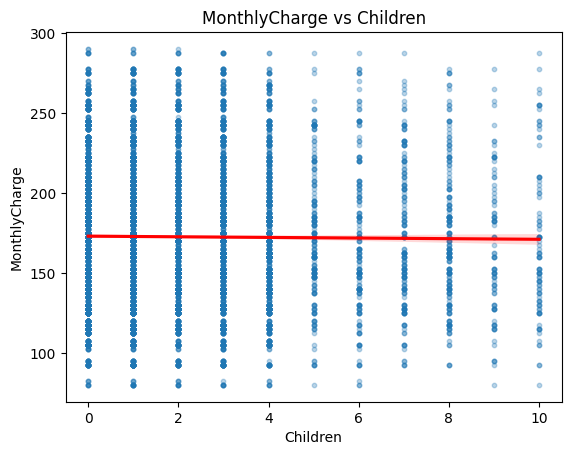

In [209]:
#Bivariate MonthlyCharge x Children


sns.regplot(
    x='Children',
    y='MonthlyCharge',
    data=df_model,
    scatter_kws={'alpha':0.3, 's':10},
    line_kws={'color':'red'}
)
plt.title('MonthlyCharge vs Children')
plt.show()

Bivariate graphs of MonthlyCharge x categoricals


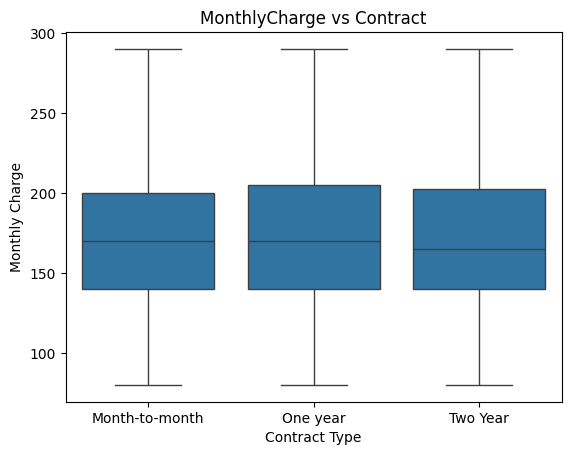

In [211]:
#Bivariate MonthlyCharge x Contract

sns.boxplot(x='Contract',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs Contract")
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charge')
plt.show()

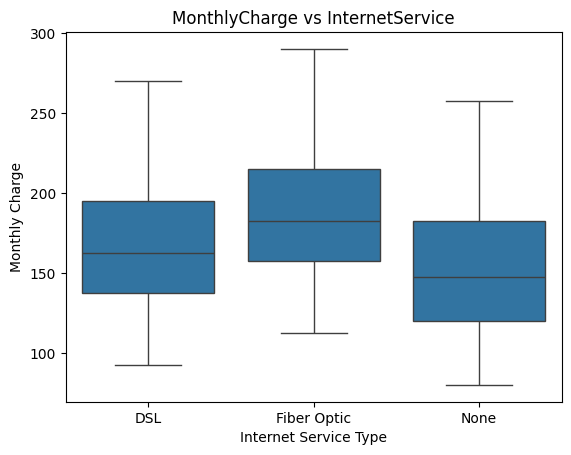

In [212]:
#Bivariate MonthlyCharge X InternetService

sns.boxplot(x='InternetService',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs InternetService")
plt.xlabel('Internet Service Type')
plt.ylabel('Monthly Charge')
plt.show()

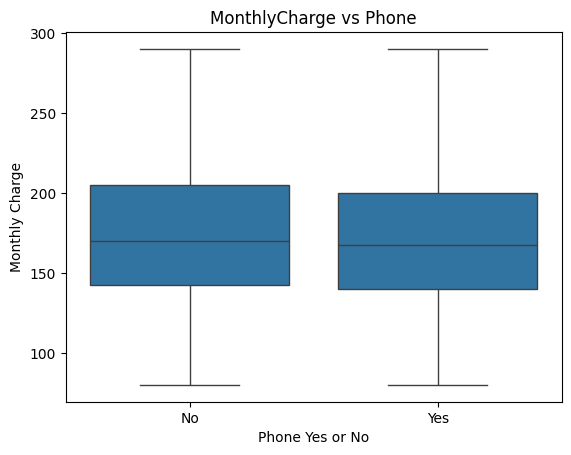

In [213]:
#Bivariate MonthlyCharge X Phone

sns.boxplot(x='Phone',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs Phone")
plt.xlabel('Phone Yes or No')
plt.ylabel('Monthly Charge')
plt.show()

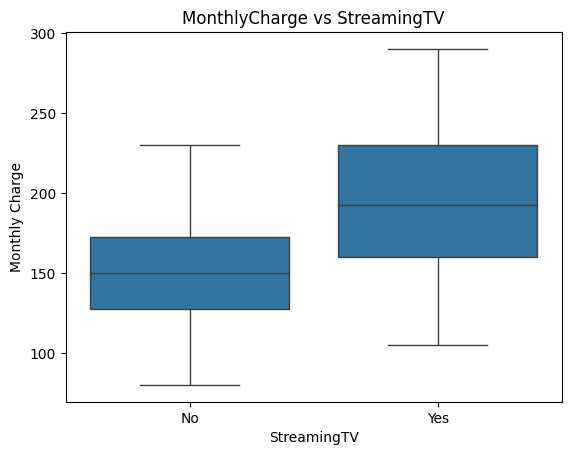

In [214]:
#Bivariate MonthlyCharge X StreamingTV 

sns.boxplot(x='StreamingTV',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs StreamingTV")
plt.xlabel('StreamingTV')
plt.ylabel('Monthly Charge')
plt.show()

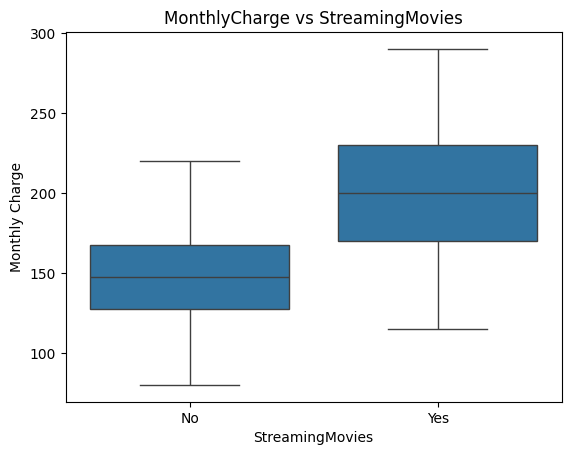

In [215]:
#Bivariate MonthlyCharge X StreamingMovies 

sns.boxplot(x='StreamingMovies',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs StreamingMovies")
plt.xlabel('StreamingMovies')
plt.ylabel('Monthly Charge')
plt.show()

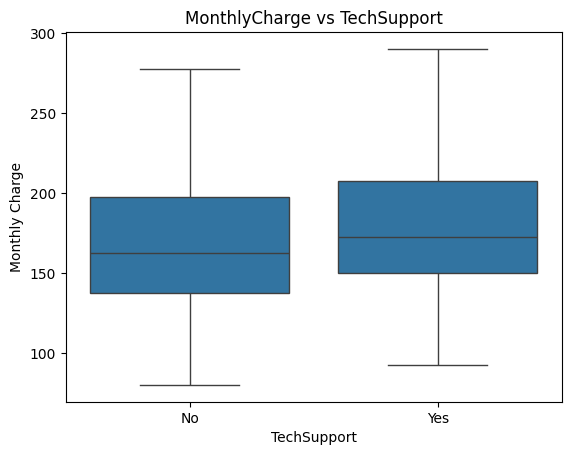

In [216]:
#Bivariate MonthlyCharge X TechSupport

sns.boxplot(x='TechSupport',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs TechSupport")
plt.xlabel('TechSupport')
plt.ylabel('Monthly Charge')

plt.show()

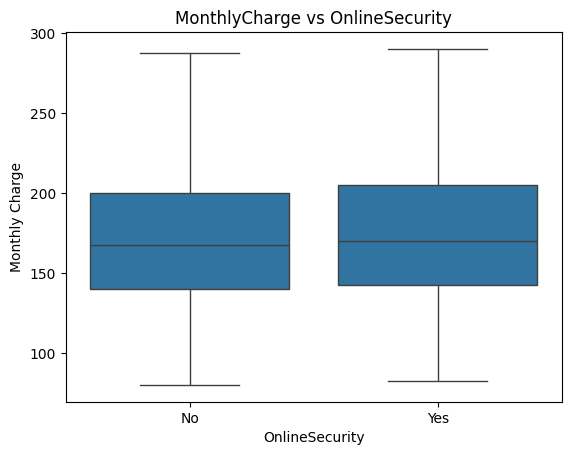

In [217]:
#Bivariate MonthlyCharge X OnlineSecurity

sns.boxplot(x='OnlineSecurity',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs OnlineSecurity")
plt.xlabel('OnlineSecurity')
plt.ylabel('Monthly Charge')

plt.show()

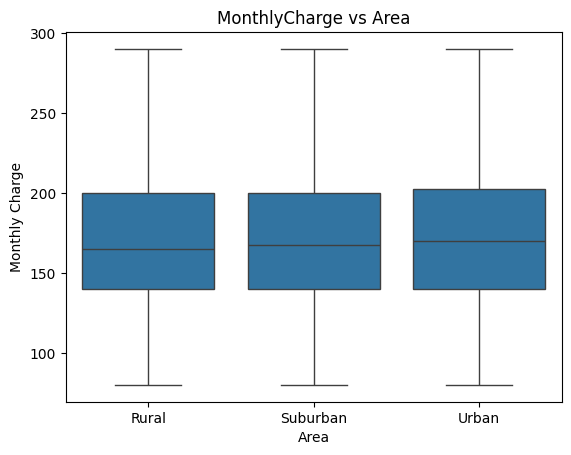

In [218]:
#Bivariate MonthlyCharge X Area

sns.boxplot(x='Area',y='MonthlyCharge',data=df_model)
plt.title("MonthlyCharge vs Area")
plt.xlabel('Area')
plt.ylabel('Monthly Charge')

plt.show()

Checking correlation between explanatory numerical variables and response


In [220]:
num_cols = ['Bandwidth_GB_Year', 'Income', 'Tenure', 'Population', 'Children']


In [221]:
print(num_cols)

['Bandwidth_GB_Year', 'Income', 'Tenure', 'Population', 'Children']


In [222]:
#Check which categorical binary variables need transformation

print(df_model.head())

   MonthlyCharge  Bandwidth_GB_Year    Income     Tenure  Population  \
0     172.455519         904.536110  28561.99   6.795513          38   
1     242.632554         800.982766  21704.77   1.156681       10446   
2     159.947583        2054.706961   9609.57  15.754144        3735   
3     119.956840        2164.579412  18925.23  17.087227       13863   
4     149.948316         271.493436  40074.19   1.670972       11352   

   Children        Contract InternetService Phone StreamingTV StreamingMovies  \
0         0        One year     Fiber Optic   Yes          No             Yes   
1         1  Month-to-month     Fiber Optic   Yes         Yes             Yes   
2         4        Two Year             DSL   Yes          No             Yes   
3         1        Two Year             DSL   Yes         Yes              No   
4         0  Month-to-month     Fiber Optic    No         Yes              No   

  TechSupport OnlineSecurity      Area  
0          No            Yes     Urban 

In [223]:
# Turn Categorical yes no's into Binary 


#df_model['Phone'] = df_model['Phone'].replace({'Yes': 1, 'No': 0})
#df_model['StreamingTV'] = df_model['StreamingTV'].replace({'Yes': 1, 'No': 0})
#df_model['StreamingMovies'] = df_model['StreamingMovies'].replace({'Yes': 1, 'No': 0})
#df_model['TechSupport'] = df_model['TechSupport'].replace({'Yes': 1, 'No': 0})
#df_model['OnlineSecurity'] = df_model['OnlineSecurity'].replace({'Yes': 1, 'No': 0})

In [224]:
print(df_model.head())

   MonthlyCharge  Bandwidth_GB_Year    Income     Tenure  Population  \
0     172.455519         904.536110  28561.99   6.795513          38   
1     242.632554         800.982766  21704.77   1.156681       10446   
2     159.947583        2054.706961   9609.57  15.754144        3735   
3     119.956840        2164.579412  18925.23  17.087227       13863   
4     149.948316         271.493436  40074.19   1.670972       11352   

   Children        Contract InternetService Phone StreamingTV StreamingMovies  \
0         0        One year     Fiber Optic   Yes          No             Yes   
1         1  Month-to-month     Fiber Optic   Yes         Yes             Yes   
2         4        Two Year             DSL   Yes          No             Yes   
3         1        Two Year             DSL   Yes         Yes              No   
4         0  Month-to-month     Fiber Optic    No         Yes              No   

  TechSupport OnlineSecurity      Area  
0          No            Yes     Urban 

In [225]:
#One hot encode categorical nominal categories

one_hot_category= ['Contract','InternetService','Area']

df_model=pd.get_dummies(df_model,
                        columns=one_hot_category,
                        drop_first=True
                       )


In [226]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   MonthlyCharge                10000 non-null  float64 
 1   Bandwidth_GB_Year            10000 non-null  float64 
 2   Income                       10000 non-null  float64 
 3   Tenure                       10000 non-null  float64 
 4   Population                   10000 non-null  int64   
 5   Children                     10000 non-null  int64   
 6   Phone                        10000 non-null  category
 7   StreamingTV                  10000 non-null  category
 8   StreamingMovies              10000 non-null  category
 9   TechSupport                  10000 non-null  category
 10  OnlineSecurity               10000 non-null  category
 11  Contract_One year            10000 non-null  bool    
 12  Contract_Two Year            10000 non-null  bool    
 13  InternetServi

In [227]:
print(df_model.columns)

Index(['MonthlyCharge', 'Bandwidth_GB_Year', 'Income', 'Tenure', 'Population',
       'Children', 'Phone', 'StreamingTV', 'StreamingMovies', 'TechSupport',
       'OnlineSecurity', 'Contract_One year', 'Contract_Two Year',
       'InternetService_Fiber Optic', 'InternetService_None', 'Area_Suburban',
       'Area_Urban'],
      dtype='str')


In [228]:

print(df_model.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   MonthlyCharge                10000 non-null  float64 
 1   Bandwidth_GB_Year            10000 non-null  float64 
 2   Income                       10000 non-null  float64 
 3   Tenure                       10000 non-null  float64 
 4   Population                   10000 non-null  int64   
 5   Children                     10000 non-null  int64   
 6   Phone                        10000 non-null  category
 7   StreamingTV                  10000 non-null  category
 8   StreamingMovies              10000 non-null  category
 9   TechSupport                  10000 non-null  category
 10  OnlineSecurity               10000 non-null  category
 11  Contract_One year            10000 non-null  bool    
 12  Contract_Two Year            10000 non-null  bool    
 13  InternetServi

In [229]:
#Rename columns, replace empty spaces at InternetService_fiber optic with no empty space inbetween

df_model.columns = (
    df_model.columns
    .str.replace(' ', '_')
)

In [230]:
print(df_model.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   MonthlyCharge                10000 non-null  float64 
 1   Bandwidth_GB_Year            10000 non-null  float64 
 2   Income                       10000 non-null  float64 
 3   Tenure                       10000 non-null  float64 
 4   Population                   10000 non-null  int64   
 5   Children                     10000 non-null  int64   
 6   Phone                        10000 non-null  category
 7   StreamingTV                  10000 non-null  category
 8   StreamingMovies              10000 non-null  category
 9   TechSupport                  10000 non-null  category
 10  OnlineSecurity               10000 non-null  category
 11  Contract_One_year            10000 non-null  bool    
 12  Contract_Two_Year            10000 non-null  bool    
 13  InternetServi

In [231]:
df_model[num_cols].corr()


,Bandwidth_GB_Year,Income,Tenure,Population,Children
Bandwidth_GB_Year,1.000000,0.003009,0.991495,-0.003902,0.025585
Income,0.003009,1.000000,0.001413,-0.008349,0.010217
Tenure,0.991495,0.001413,1.000000,-0.003559,-0.005091
Population,-0.003902,-0.008349,-0.003559,1.000000,-0.005877
Children,0.025585,0.010217,-0.005091,-0.005877,1.000000


In [232]:
#Saving prepared dataset for Linear regression as CSV

df.to_csv('C5_prepared_Dataset.csv', index=False)


D.1. 

Construct an initial multiple linear regression model from all independent variables that were identified

In [234]:
#Create first model with all selected variables from C2

initial_model = ols("MonthlyCharge ~ Bandwidth_GB_Year + Income + Tenure + Population + Children + Phone + StreamingTV + StreamingMovies"
                    "+ TechSupport + OnlineSecurity + Contract_One_year + Contract_Two_Year + InternetService_Fiber_Optic "
                    "+ InternetService_None + Area_Suburban + Area_Urban", data = df_model).fit()

#summary 
print(initial_model.summary())


                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     3370.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:36:09   Log-Likelihood:                -42505.
No. Observations:               10000   AIC:                         8.504e+04
Df Residuals:                    9983   BIC:                         8.517e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

Backward Stepwise elimination
Remove Least significant feature based on p-value at each iteration which improves performance of the model
P value more than .05 = not significant
P>|t| > 0.05 =  remove

Adj.Rsquared is high meaning the data does depict variation to Y. 

Prob (F-Statistic) lower is better = Overall significance of the regression. This model is very significant






In [236]:
#removing Phone for backward stepwise elimination 

model2 = ols("MonthlyCharge ~ Bandwidth_GB_Year + Income + Tenure + Population + Children + StreamingTV + StreamingMovies"
                    "+ TechSupport + OnlineSecurity + Contract_One_year + Contract_Two_Year + InternetService_Fiber_Optic "
                    "+ InternetService_None + Area_Suburban + Area_Urban", data = df_model).fit()



In [237]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     3595.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:36:09   Log-Likelihood:                -42505.
No. Observations:               10000   AIC:                         8.504e+04
Df Residuals:                    9984   BIC:                         8.516e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

R-squared + adj is still the same. Phone variable did not matter, this proves Phone is useless in causing variation to Y

F-statistics is still 0 meaning the overral dataset did not lose any significance

Least significant variables=
Contract_one_year
Contract_two_year
Area
Income
Population

Next model will remove Contract 

In [239]:
#removing Contract for backward stepwise elimination 

model3 = ols("MonthlyCharge ~ Bandwidth_GB_Year + Income + Tenure + Population + Children + StreamingTV + StreamingMovies"
                    "+ TechSupport + OnlineSecurity + InternetService_Fiber_Optic "
                    "+ InternetService_None + Area_Suburban + Area_Urban", data = df_model).fit()



In [240]:
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     4148.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:36:09   Log-Likelihood:                -42506.
No. Observations:               10000   AIC:                         8.504e+04
Df Residuals:                    9986   BIC:                         8.514e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

R-Squared + Adj R squared is still the same proving that removing the contract category did not make the model less statistically significant. 

Prob(F-Statistic) still stays at 0.00 proving that the overral significance of the model is strong

Next variable to remove: Area



In [242]:
#removing Area for backward stepwise elimination 

model4 = ols("MonthlyCharge ~ Bandwidth_GB_Year + Income + Tenure + Population + Children + StreamingTV + StreamingMovies"
                    "+ TechSupport + OnlineSecurity + InternetService_Fiber_Optic + InternetService_None", data = df_model).fit()



In [243]:
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     4903.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:36:09   Log-Likelihood:                -42507.
No. Observations:               10000   AIC:                         8.504e+04
Df Residuals:                    9988   BIC:                         8.512e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

R-Squared + Adj-R-Squared has not changed. Proving Area does not statistically influence Y(MonthlyCharge)
Prob(F-Statistic) also has stayed the same at 0.00 proving this model has stayed meaningful 

Least significant variables by p values > 0.05:
Income
Population


Next variable to remove for Backwward Stepwise elimination:



In [245]:
#removing Income for backward stepwise elimination 

model5 = ols("MonthlyCharge ~ Bandwidth_GB_Year + Tenure + Population + Children + StreamingTV + StreamingMovies"
                    "+ TechSupport + OnlineSecurity + InternetService_Fiber_Optic + InternetService_None", data = df_model).fit()



In [246]:
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     5393.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:36:09   Log-Likelihood:                -42507.
No. Observations:               10000   AIC:                         8.504e+04
Df Residuals:                    9989   BIC:                         8.512e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

Removing Income from the model(5)

R-squared + Adj R-squared has showed to stay the same values at 0.844. The current variables has not loss any variation on Y(MonthlyCharge)
Prob(F-Statistic) has showed to stay at 0.00. The model is still significant all over the current variables

Next variable to remove by p values > 0.05:
Population



In [248]:
#removing Population for backward stepwise elimination 

model6 = ols("MonthlyCharge ~ Bandwidth_GB_Year + Tenure + Children + StreamingTV + StreamingMovies"
                    "+ TechSupport + OnlineSecurity + InternetService_Fiber_Optic + InternetService_None", data = df_model).fit()




In [249]:
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     5992.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:36:09   Log-Likelihood:                -42507.
No. Observations:               10000   AIC:                         8.503e+04
Df Residuals:                    9990   BIC:                         8.511e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

R-squared + adj R-squared has stayed the same
Prob(F-Statistic) has stayed the same

This is the final model

Will be doing an experiment model by removing a significant variable to harm the model (TEST!)




In [251]:
#TEST MODEL EXPERIMENT FOR HARM 
#Choosing variable to remove to see model decrease in effectiveness/significance 
#Removing Children 

EXmodel = ols("MonthlyCharge ~ Bandwidth_GB_Year + Tenure + StreamingTV + StreamingMovies"
                    "+ TechSupport + OnlineSecurity + InternetService_Fiber_Optic + InternetService_None", data = df_model).fit()




In [252]:
print(EXmodel.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyCharge   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     5250.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:36:09   Log-Likelihood:                -43541.
No. Observations:               10000   AIC:                         8.710e+04
Df Residuals:                    9991   BIC:                         8.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

Experimental model has showed to decrease in R-squared proving that variable Children does contribute to the variation of the response variable 

Text(0.5, 1.0, 'Residuals vs Fitted values')

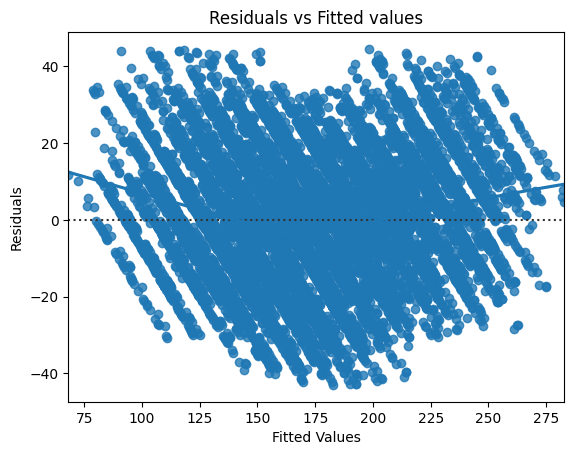

In [254]:
#Residual plot

fitted_vals = model6.fittedvalues
resid = model6.resid


sns.residplot(x=fitted_vals, y=resid, lowess=True)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values")

In [255]:
#E2 Professors Middleton webinar ask for predicted values of Y
#Get predicted values of Y, show the first 5 lines 
predicted_y = model6.fittedvalues
print(predicted_y.head())


0    182.993996
1    238.460698
2    153.471996
3    145.961967
4    160.871131
dtype: float64


Calculating model's residual standard error
Smaller residual standard error is better
RSE = typical size of the residuals

"you take the square root of the mse_resid attribute to get the RSE"




In [257]:
#Calculating reduced models RSE

rse= np.sqrt(model6.mse_resid)
print(rse)


print("Residual Standard Error of Reduced Model:",rse)

16.984499693137618
Residual Standard Error of Reduced Model: 16.984499693137618
